# Step 3 — Cross-domain generalization (reactivation detection)

**Does an animacy decoder trained only on passive functional-localizer (FL)
viewing generalize to the real-time task's encoding and retrieval phases — i.e.
does a perception-trained decoder read out a *memory* during recall?**

Method (King & Dehaene temporal generalization, across domains). Fit one
`GeneralizingEstimator` on **all** FL timepoints, then score it across the recall
window → a square **(FL-train-time × recall-test-time)** AUC map. No CV: the
encoding/retrieval recordings were never in FL training. **Encoding is the
positive control** (an image is on screen), **retrieval is the result** (pure
recall). Deployment-faithful: train on offline FL epochs, test on
real-time-processed recall features (step 2 bounded the pipeline's own cost).

**Honest significance.** The headline is the max AUC over the **whole map** (both
axes), with the label-shuffle null taking the same global max each time, so the
2-D latency search is fully corrected (`matrix_permutation`). We also report the
**deployed** FL timepoint's own row as a secondary "at the operating point that
ships" readout (`row_permutation`).

**Both decoders** (`animate`, `inanimate`) are run and reported independently,
side by side, never pooled — including the cross-subject Stouffer combination.


In [ ]:
%load_ext autoreload
%autoreload 2

from analysis_lib import context
REPO_ROOT = context.bootstrap()

from pathlib import Path

import joblib
import matplotlib
matplotlib.use("inline")
# Save every figure with a tight bounding box so titles/suptitles/labels drawn
# near or past the figure edge aren't cropped in PNGs.
matplotlib.rcParams["savefig.bbox"] = "tight"
matplotlib.rcParams["savefig.pad_inches"] = 0.1
import matplotlib.pyplot as plt
import mne
mne.set_log_level("ERROR")
import numpy as np

from backend.core import preprocessing_constants as pc
from backend.offline_phase.utils import get_task_data
from analysis_lib import cross_domain, online_validation, plots, sources, streaming


def show_table(rows, cols, *, csv_path=None, width=13):
    # Print an aligned text table (rows = list of dicts) and optionally save CSV.
    # No pandas (matches the other analysis notebooks): first column left-
    # justified (labels), the rest right-justified.
    import csv as _csv
    if not rows:
        print("(no rows)")
        return
    def fmt(v):
        return f"{v:.4f}" if isinstance(v, float) else str(v)
    sep = "  "
    head = str(cols[0]).ljust(width) + sep + sep.join(str(c).rjust(width) for c in cols[1:])
    print(head)
    print("-" * len(head))
    for r in rows:
        print(fmt(r.get(cols[0], "")).ljust(width) + sep
              + sep.join(fmt(r.get(c, "")).rjust(width) for c in cols[1:]))
    if csv_path is not None:
        with open(csv_path, "w", newline="") as fh:
            w = _csv.DictWriter(fh, fieldnames=cols)
            w.writeheader()
            w.writerows(rows)

## Knobs

Each subject is a `SessionPaths`-shaped output dir with `epochs/` **and**
`models/decoder_pipeline.joblib` (its frozen `online_state` drives the online
pipeline, and its trained timepoints mark the deployed operating point). The test
window is the FL epoch window (`preprocessing_constants.EPOCH_TMIN/TMAX`), so the
map is square and the diagonal is directly interpretable. Widen `TMAX` later to
search a longer recall window.


In [14]:
SUBJECTS = ["data/sub_001", "data/sub_002", "data/sub_003"]
SUBJECT_NAMES = {s: s.split("/")[-1] for s in SUBJECTS}

TMIN, TMAX = pc.EPOCH_TMIN, pc.EPOCH_TMAX   # -0.2..1.0 s (matches FL train window)
MAX_SECONDS = None       # None = whole recording
N_PERM = 2000            # label-shuffle permutations (whole-map max null)
N_BOOT = 2000            # bootstrap resamples for the headline CI
SEED = 0

SOURCES = ["encoding", "retrieval"]
FEATURE_BUILDER = {"encoding": sources.build_encoding_features,
                   "retrieval": sources.build_retrieval_features}

ASSETS_DIR = REPO_ROOT / "tests" / "notebooks" / "analysis" / "report_assets" / "step3"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
ASSETS_DIR


WindowsPath('C:/Users/itaip/projects/live-reactivation-decoder/tests/notebooks/analysis/report_assets/step3')

## Load contexts + resolve each subject's task recording

`context.load_context` (needs the trained artifact). The task recording (the one
carrying `learning_*`/`retrieval_*` markers) is auto-picked from `ctx.raw_dirs`;
override via `TASK_DIR_KEY` if a subject has an ambiguous layout.


In [15]:
TASK_DIR_KEY = {}  # {subject: raw_dir_key} override; else auto-pick the "task" dir


def resolve_task_dir(ctx, subject):
    keys = list(ctx.raw_dirs)
    if subject in TASK_DIR_KEY:
        return ctx.raw_dirs[TASK_DIR_KEY[subject]]
    task = [k for k in keys if "task" in k.lower()]
    if len(task) == 1:
        return ctx.raw_dirs[task[0]]
    raise ValueError(f"{subject}: ambiguous raw dirs {keys} -- set TASK_DIR_KEY[{subject!r}]")


ctxs = {s: context.load_context(s) for s in SUBJECTS}
task_dirs = {s: resolve_task_dir(ctxs[s], s) for s in SUBJECTS}
TASK_NAMES = [t["name"] for t in ctxs[SUBJECTS[0]].settings.get_decoder_settings()["tasks"]]
print("decoders:", TASK_NAMES)
{SUBJECT_NAMES[s]: str(task_dirs[s]) for s in SUBJECTS}


decoders: ['animate decoder', 'inanimate decoder']


{'sub_001': 'C:\\Users\\itaip\\projects\\live-reactivation-decoder\\data\\sub_001\\task',
 'sub_002': 'C:\\Users\\itaip\\projects\\live-reactivation-decoder\\data\\sub_002\\task',
 'sub_003': 'C:\\Users\\itaip\\projects\\live-reactivation-decoder\\data\\sub_003\\task'}

## Replay each task recording once through the online pipeline

One `run_online_stream` pass per subject yields the multi-channel online feature
stream; from it we epoch **encoding** and **retrieval** feature trials once each,
and read the offline FL epochs (the train side). All reused below. *(This is the
slowest cell — a full recording is ~2M samples; progress prints per stage.)*


In [16]:
replay = {}  # subject -> dict(fl_epochs, feats={source: dict(t_grid, X_all, cat_labels, trials)})
for i, s in enumerate(SUBJECTS, 1):
    ctx = ctxs[s]
    name = SUBJECT_NAMES[s]
    print(f"[{i}/{len(SUBJECTS)}] {name}: loading {task_dirs[s].name} ...", flush=True)
    raw, eeg, sfreq = streaming.load_recording(task_dirs[s], MAX_SECONDS)
    print(f"    replaying {eeg.shape[0]:,} samples through the online pipeline ...", flush=True)
    features, out_samples, fs_out = streaming.run_online_stream(ctx.preproc, eeg)
    n_times = int(out_samples.max()) + 1
    fl_epochs = online_validation.load_offline_epochs(ctx)
    feats = {}
    for src in SOURCES:
        t_grid, X_all, cat_labels, trials, info = FEATURE_BUILDER[src](
            ctx, raw, features, out_samples, sfreq, fs_out,
            tmin=TMIN, tmax=TMAX, n_times=n_times)
        assert len(t_grid) == len(fl_epochs.times), "train/test time grids differ"
        feats[src] = dict(t_grid=t_grid, X_all=X_all, cat_labels=cat_labels, trials=trials)
        print(f"    {info}", flush=True)
    replay[s] = dict(fl_epochs=fl_epochs, feats=feats)
    print(f"    FL epochs {fl_epochs.get_data().shape}\n", flush=True)
print("replay done.")


[1/3] sub_001: loading task ...
    replaying 2,018,706 samples through the online pipeline ...
    [encoding features] 66/66 image onsets epoched | by true category {'inanimate': 33, 'animate': 33}
    [retrieval features] 120/120 cued trials epoched, 114 recalled | by true category {'animate': 60, 'inanimate': 60}
    FL epochs (604, 64, 121)

[2/3] sub_002: loading task ...
    replaying 2,287,211 samples through the online pipeline ...
    [encoding features] 66/66 image onsets epoched | by true category {'animate': 33, 'inanimate': 33}
    [retrieval features] 120/120 cued trials epoched, 114 recalled | by true category {'inanimate': 60, 'animate': 60}
    FL epochs (604, 64, 121)

[3/3] sub_003: loading task ...
    replaying 2,179,291 samples through the online pipeline ...
    [encoding features] 66/66 image onsets epoched | by true category {'inanimate': 33, 'animate': 33}
    [retrieval features] 120/120 cued trials epoched, 119 recalled | by true category {'inanimate': 60, '

## Cross-domain generalization — per subject × decoder × source

For each cell: fit the generalizer on FL (cached per subject×decoder), map it onto
the recall window, and compute the whole-map corrected headline (`max_auc` at
`train × test` latency, permutation `p`, bootstrap CI) plus the deployed-row
secondary. *(Progress prints per cell; each does a `GeneralizingEstimator` score
+ permutations.)*


In [17]:
results = {}     # (subject, source, task) -> result dict
ge_cache = {}    # (subject, task) -> fitted GeneralizingEstimator (source-independent)


def get_ge(s, task_cfg):
    key = (s, task_cfg["name"])
    if key not in ge_cache:
        settings = ctxs[s].settings.get_decoder_settings()
        X_fl, y_fl = get_task_data(replay[s]["fl_epochs"], task_cfg)
        ge_cache[key] = cross_domain.fit_generalizer(X_fl, y_fl, settings)
    return ge_cache[key]


total = len(SUBJECTS) * len(SOURCES) * len(TASK_NAMES)
done = 0
for s in SUBJECTS:
    ctx = ctxs[s]
    settings = ctx.settings.get_decoder_settings()
    fl_times = replay[s]["fl_epochs"].times
    for src in SOURCES:
        f = replay[s]["feats"][src]
        for task_cfg in settings["tasks"]:
            name = task_cfg["name"]
            ge = get_ge(s, task_cfg)
            X_test, y_test = cross_domain.binary_test_set(f["X_all"], f["cat_labels"], task_cfg)
            dep_row = cross_domain.row_index_for_timepoint(fl_times, ctx.task_tp(name))
            res = cross_domain.cross_domain_result(
                ge, X_test, y_test, deployed_row_idx=dep_row,
                n_perm=N_PERM, n_boot=N_BOOT, rng=np.random.default_rng(SEED))
            res.update(subject=SUBJECT_NAMES[s], source=src, task=name, times=fl_times)
            results[(s, src, name)] = res
            done += 1
            print(f"[{done}/{total}] {SUBJECT_NAMES[s]:>8} | {src:>9} | {name:>18}: "
                  f"max_auc {res['max_auc']:.3f} @ train {fl_times[res['fl_idx']]:+.2f}s "
                  f"x test {fl_times[res['test_idx']]:+.2f}s  p={res['p_value']:.4f}  "
                  f"CI[{res['ci'][0]:.3f},{res['ci'][1]:.3f}]  "
                  f"(deployed diag {res['deployed']['diag_auc']:.3f} p={res['deployed']['p_value']:.4f})",
                  flush=True)
print("\ncross-domain scoring done.")


[1/12]  sub_001 |  encoding |    animate decoder: max_auc 0.746 @ train +0.36s x test -0.13s  p=0.3878  CI[0.617,0.856]  (deployed diag 0.390 p=0.8486)
[2/12]  sub_001 |  encoding |  inanimate decoder: max_auc 0.754 @ train +0.12s x test +0.89s  p=0.2564  CI[0.623,0.868]  (deployed diag 0.591 p=0.4643)
[3/12]  sub_001 | retrieval |    animate decoder: max_auc 0.673 @ train +0.68s x test -0.01s  p=0.5907  CI[0.571,0.765]  (deployed diag 0.451 p=0.6512)
[4/12]  sub_001 | retrieval |  inanimate decoder: max_auc 0.667 @ train +0.27s x test +0.97s  p=0.6457  CI[0.576,0.760]  (deployed diag 0.467 p=0.5532)
[5/12]  sub_002 |  encoding |    animate decoder: max_auc 0.747 @ train +0.88s x test +0.48s  p=0.2324  CI[0.622,0.858]  (deployed diag 0.418 p=0.9345)
[6/12]  sub_002 |  encoding |  inanimate decoder: max_auc 0.688 @ train +0.18s x test +0.29s  p=0.9320  CI[0.551,0.818]  (deployed diag 0.555 p=0.2854)
[7/12]  sub_002 | retrieval |    animate decoder: max_auc 0.679 @ train +0.82s x test +0

## Per-subject headline table

`max_auc` / `train_s` / `test_s` / `p` / CI = the whole-map corrected headline;
`dep_*` = the shipped decoder's own FL timepoint (diagonal AUC + its row p-value).


In [18]:
rows = []
for (s, src, name), r in results.items():
    rows.append(dict(
        subject=r["subject"], source=src, decoder=name,
        n=r["n_trials"], pos=r["n_pos"],
        max_auc=round(r["max_auc"], 3),
        train_s=round(float(r["times"][r["fl_idx"]]), 2),
        test_s=round(float(r["times"][r["test_idx"]]), 2),
        p=round(r["p_value"], 4),
        ci_lo=round(r["ci"][0], 3), ci_hi=round(r["ci"][1], 3),
        dep_diag=round(r["deployed"]["diag_auc"], 3),
        dep_p=round(r["deployed"]["p_value"], 4),
    ))
rows.sort(key=lambda r: (r["source"], r["decoder"], r["subject"]))
show_table(rows,
           ["subject", "source", "decoder", "n", "pos", "max_auc", "train_s",
            "test_s", "p", "ci_lo", "ci_hi", "dep_diag", "dep_p"],
           csv_path=ASSETS_DIR / "per_subject_headline.csv")


subject               source        decoder              n            pos        max_auc        train_s         test_s              p          ci_lo          ci_hi       dep_diag          dep_p
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
sub_001             encoding  animate decoder             66             33         0.7460         0.3600        -0.1300         0.3878         0.6170         0.8560         0.3900         0.8486
sub_002             encoding  animate decoder             66             33         0.7470         0.8800         0.4800         0.2324         0.6220         0.8580         0.4180         0.9345
sub_003             encoding  animate decoder             66             33         0.7480        -0.0700         0.3700         0.1674         0.6200         0.8700         0.5450         0.4753
sub_001             enco

## Cross-domain TGM heatmaps

One figure per source; rows = subjects, cols = decoders. Chance (0.5) sits
near-white (`RdBu_r`, GUI convention).


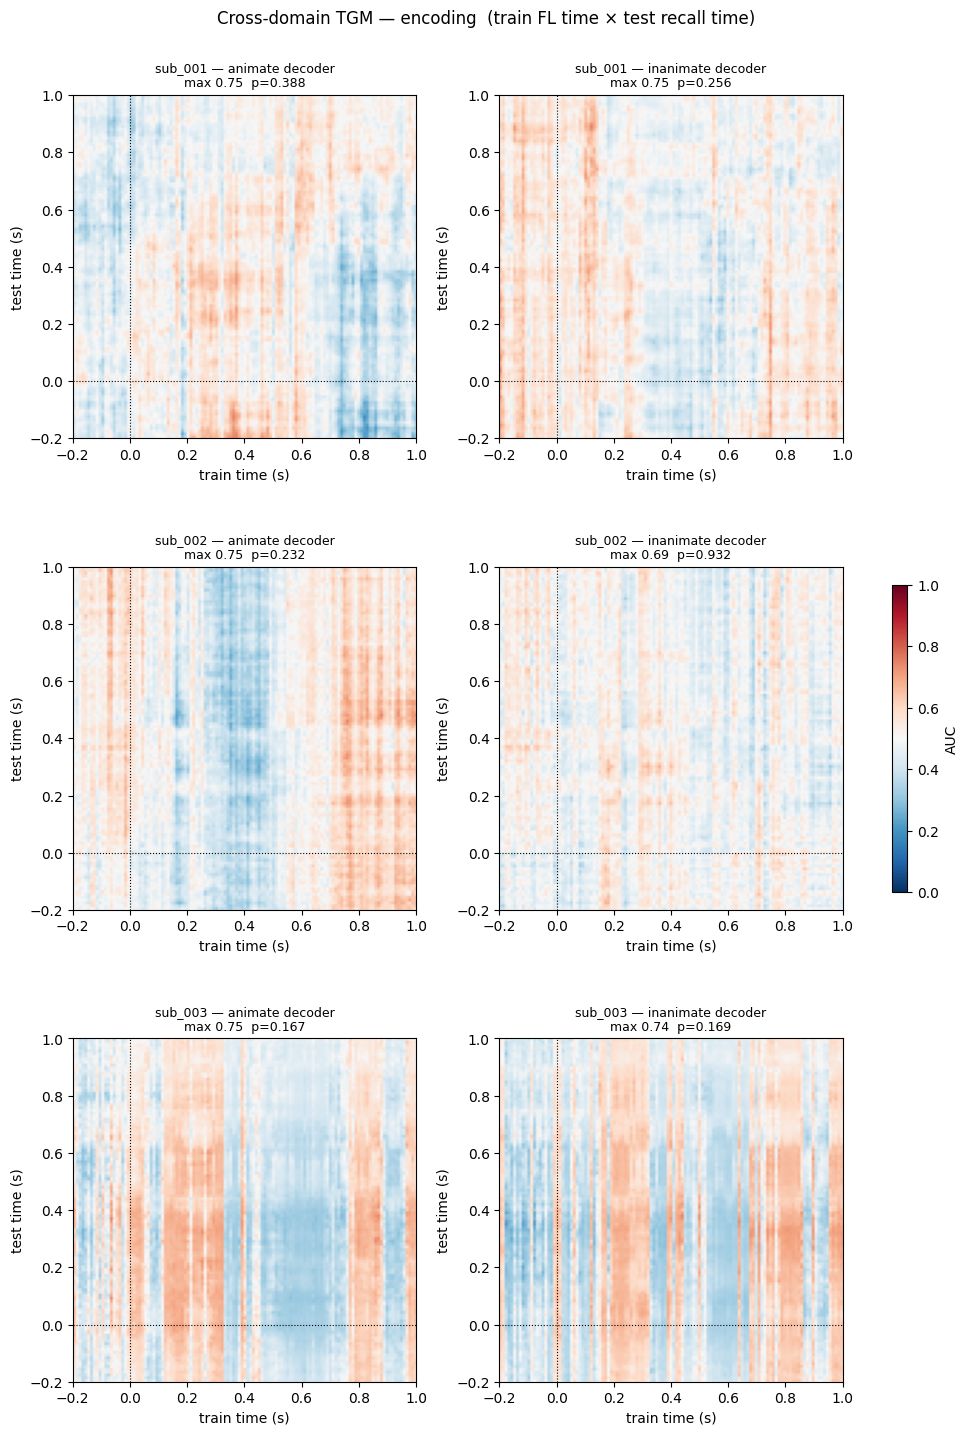

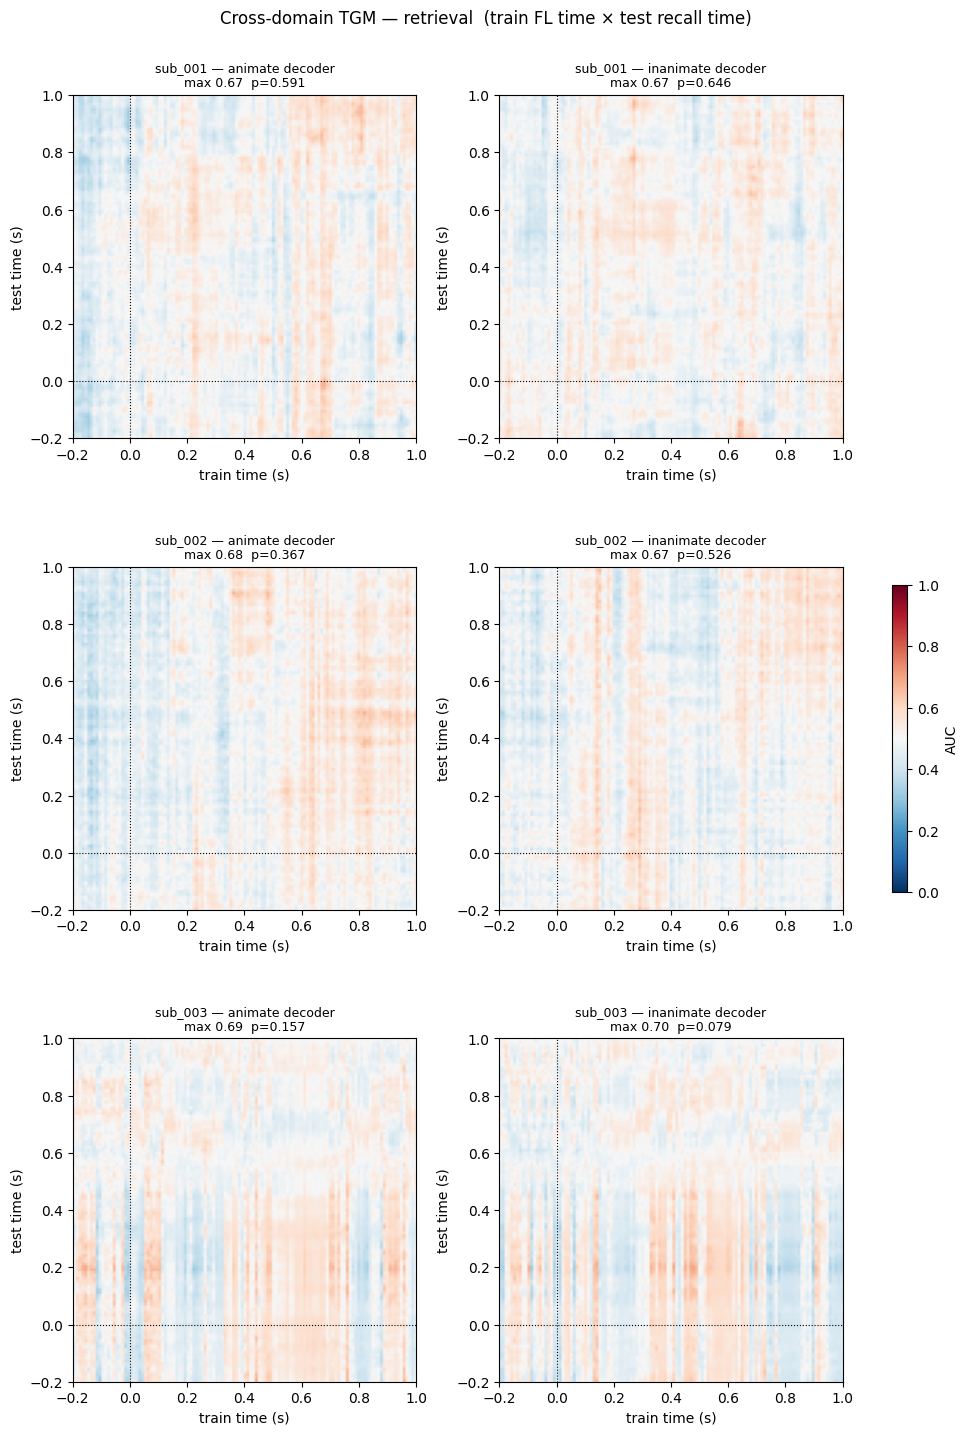

In [19]:
for src in SOURCES:
    nrows, ncols = len(SUBJECTS), len(TASK_NAMES)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.8 * nrows),
                             squeeze=False, constrained_layout=True)
    im = None
    for i, s in enumerate(SUBJECTS):
        for j, name in enumerate(TASK_NAMES):
            r = results[(s, src, name)]
            ax = axes[i][j]
            im = plots.plot_tgm_matrix(r["tgm"], r["times"], "", ax=ax)
            ax.set_title(f"{r['subject']} — {name}\nmax {r['max_auc']:.2f}  p={r['p_value']:.3f}",
                         fontsize=9)
    fig.colorbar(im, ax=list(axes.ravel()), fraction=0.02, label="AUC")
    fig.suptitle(f"Cross-domain TGM — {src}  (train FL time × test recall time)")
    plt.savefig(ASSETS_DIR / f"tgm_{src}.png", dpi=130)
    plt.show()


## Diagonal AUC over time (train == test)

Thin per-subject lines + bold mean, per decoder per source — "consistency across
subjects," not a powered group test.


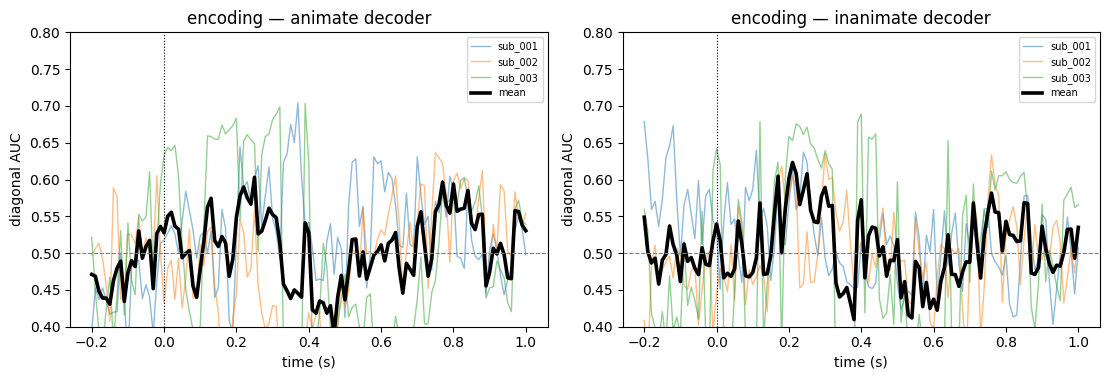

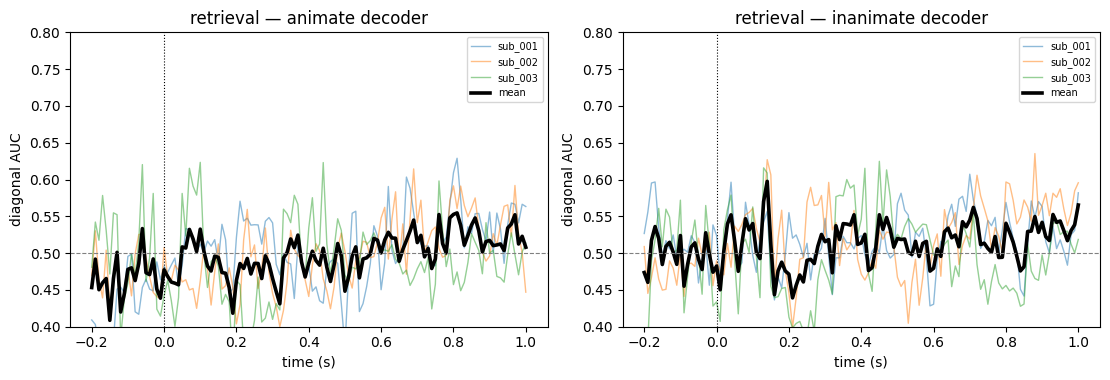

In [20]:
for src in SOURCES:
    fig, axes = plt.subplots(1, len(TASK_NAMES), figsize=(5.6 * len(TASK_NAMES), 3.9),
                             squeeze=False)
    for j, name in enumerate(TASK_NAMES):
        ax = axes[0][j]
        diags = []
        for s in SUBJECTS:
            r = results[(s, src, name)]
            ax.plot(r["times"], r["diag"], lw=1.0, alpha=0.5, label=r["subject"])
            diags.append(r["diag"])
        times = results[(SUBJECTS[0], src, name)]["times"]
        ax.plot(times, np.mean(diags, axis=0), lw=2.6, color="k", label="mean")
        ax.axhline(0.5, color="gray", ls="--", lw=0.8)
        ax.axvline(0.0, color="k", ls=":", lw=0.8)
        ax.set(title=f"{src} — {name}", xlabel="time (s)", ylabel="diagonal AUC",
               ylim=(0.4, 0.8))
        ax.legend(fontsize=7, loc="upper right")
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / f"diag_{src}.png", dpi=130, bbox_inches="tight")
    plt.show()


## Cross-subject combination (Stouffer)

Per decoder, per source: combine the 3 subjects' one-sided permutation p-values
into a single meta z / combined p. Never pooled across decoders.


In [21]:
srows = []
for src in SOURCES:
    for name in TASK_NAMES:
        ps = [results[(s, src, name)]["p_value"] for s in SUBJECTS]
        z, p_comb = cross_domain.stouffer(ps)
        srows.append(dict(
            source=src, decoder=name,
            p_per_subject=str([round(p, 4) for p in ps]),
            stouffer_z=round(z, 3), combined_p=round(p_comb, 5),
        ))
show_table(srows, ["source", "decoder", "p_per_subject", "stouffer_z", "combined_p"],
           csv_path=ASSETS_DIR / "stouffer.csv", width=18)


source                         decoder       p_per_subject          stouffer_z          combined_p
--------------------------------------------------------------------------------------------------
encoding               animate decoder  [0.3878, 0.2324, 0.1674]              1.1430              0.1264
encoding             inanimate decoder  [0.2564, 0.932, 0.1689]              0.0700              0.4719
retrieval              animate decoder  [0.5907, 0.3668, 0.1569]              0.6460              0.2593
retrieval            inanimate decoder  [0.6457, 0.5257, 0.0795]              0.5600              0.2876


## Secondary — retrieval, successful-recall trials only

The theoretically cleaner set (reactivation should need successful recall), at the
cost of fewer trials. Whole-map headline on the recalled subset; a decoder whose
subset drops to one class is skipped with a note.


In [22]:
rec_rows = []
for s in SUBJECTS:
    ctx = ctxs[s]
    settings = ctx.settings.get_decoder_settings()
    f = replay[s]["feats"]["retrieval"]
    mask = np.array([bool(t["recalled"]) for t in f["trials"]])
    for task_cfg in settings["tasks"]:
        name = task_cfg["name"]
        Xr, catr = f["X_all"][mask], f["cat_labels"][mask]
        try:
            X_test, y_test = cross_domain.binary_test_set(Xr, catr, task_cfg)
        except ValueError as e:
            rec_rows.append(dict(subject=SUBJECT_NAMES[s], decoder=name,
                                 n=int(mask.sum()), note=str(e)[:50]))
            print(f"{SUBJECT_NAMES[s]} | {name}: skipped ({e})", flush=True)
            continue
        res = cross_domain.cross_domain_result(
            get_ge(s, task_cfg), X_test, y_test,
            n_perm=N_PERM, n_boot=N_BOOT, rng=np.random.default_rng(SEED))
        rec_rows.append(dict(subject=SUBJECT_NAMES[s], decoder=name, n=res["n_trials"],
                             max_auc=round(res["max_auc"], 3), p=round(res["p_value"], 4)))
        print(f"{SUBJECT_NAMES[s]} | {name}: n={res['n_trials']} "
              f"max_auc {res['max_auc']:.3f} p={res['p_value']:.4f}", flush=True)
show_table(rec_rows, ["subject", "decoder", "n", "max_auc", "p", "note"],
           csv_path=ASSETS_DIR / "recalled_only.csv")


sub_001 | animate decoder: n=114 max_auc 0.663 p=0.8416
sub_001 | inanimate decoder: n=114 max_auc 0.667 p=0.7256
sub_002 | animate decoder: n=114 max_auc 0.684 p=0.3543
sub_002 | inanimate decoder: n=114 max_auc 0.665 p=0.6547
sub_003 | animate decoder: n=119 max_auc 0.692 p=0.1594
sub_003 | inanimate decoder: n=119 max_auc 0.700 p=0.0935
subject              decoder              n        max_auc              p           note
----------------------------------------------------------------------------------------
sub_001        animate decoder            114         0.6630         0.8416               
sub_001        inanimate decoder            114         0.6670         0.7256               
sub_002        animate decoder            114         0.6840         0.3543               
sub_002        inanimate decoder            114         0.6650         0.6547               
sub_003        animate decoder            119         0.6920         0.1594               
sub_003        inanim

## Save summary

One joblib with every result (arrays as lists) + the Stouffer table, for the
report's results chapter.


In [23]:
def _ser(v):
    return v.tolist() if isinstance(v, np.ndarray) else v


summary = {
    "window": [TMIN, TMAX], "n_perm": N_PERM, "n_boot": N_BOOT, "seed": SEED,
    "subjects": SUBJECT_NAMES, "decoders": TASK_NAMES,
    "times": results[(SUBJECTS[0], SOURCES[0], TASK_NAMES[0])]["times"].tolist(),
    "results": {
        f"{SUBJECT_NAMES[s]}|{src}|{name}": {k: _ser(v) for k, v in results[(s, src, name)].items()
                                             if k != "times"}
        for (s, src, name) in results
    },
    "stouffer": srows,
    "recalled_only": rec_rows,
}
out_path = ASSETS_DIR / "cross_domain_summary.joblib"
joblib.dump(summary, out_path)
print("saved:", out_path)


saved: C:\Users\itaip\projects\live-reactivation-decoder\tests\notebooks\analysis\report_assets\step3\cross_domain_summary.joblib
